# KL divergence computation for MGD on LAGRANGIAN TURBULENCE data 

In [2]:
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys
import copy
from types import SimpleNamespace

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_experiment import * 
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


In [3]:
import math
def compute_expected_kl_divergence(theta_runs, phi_X_list):
    """
    E_runs[ log E_X[ exp(-(theta_n - theta_star)^T phi_n(X)) ] ]

    Args:
        theta_runs: [N_runs, T, num_features] (or list of [T, num_features])
        phi_X_list: list of length N_runs, each [B, num_features] -- run n's
                    OWN phi_X, evaluated with that seed's own fitted potentials.
                    (Not a single shared phi_X: theta_n lives in the basis
                    defined by that seed's own active statistics.)
        theta_star: computed here as mean(theta_runs, dim=0) -- ASSUMPTION,
                    see caveat below.
    """
    if isinstance(theta_runs, list):
        theta_runs = torch.stack(theta_runs)
    N_runs, T, num_params = theta_runs.shape

    assert len(phi_X_list) == N_runs, (
        f"phi_X_list has {len(phi_X_list)} entries but theta_runs has {N_runs} runs"
    )
    for n, phi_X_n in enumerate(phi_X_list):
        assert phi_X_n.shape[-1] == num_params, (
            f"run {n}: phi_X has {phi_X_n.shape[-1]} features, "
            f"theta has {num_params}"
        )

    device = theta_runs.device
    theta_star = theta_runs.mean(dim=0)  # [T, num_params]
    kl_divergence_t = torch.zeros(T, device=device, dtype=torch.float64)

    for n in range(N_runs):
        theta_n = theta_runs[n]                              # [T, num_params]
        phi_X_n = phi_X_list[n].to(device)                    # [B_n, num_params]
        B_n = phi_X_n.shape[0]
        log_B_n = math.log(B_n)

        negative_delta_theta = -(theta_n - theta_star)         # [T, num_params]
        dot_product = torch.matmul(negative_delta_theta, phi_X_n.T)  # [T, B_n]
        log_inner = torch.logsumexp(dot_product.double(), dim=1) - log_B_n  # [T]
        kl_divergence_t += log_inner

    kl_divergence_t /= N_runs
    return kl_divergence_t.to(theta_runs.dtype)

from pathlib import Path

# Persistent across reruns, same pattern as `results`
if 'config_by_seed' not in locals() and 'config_by_seed' not in globals():
    config_by_seed = {}
if 'potentials_by_seed' not in locals() and 'potentials_by_seed' not in globals():
    potentials_by_seed = {}

def get_potentials_for_seed(key, M, base_args, root, device):
    """Lazily load+cache a seed's fitted potentials, reconstructing from disk
    if this session doesn't have them cached yet."""
    if key in potentials_by_seed:
        return potentials_by_seed[key]
    if key not in config_by_seed:
        raise KeyError(
            f"No resolved_config recorded for {key} — it was probably loaded into "
            f"`results` in an earlier session/cell before config_by_seed existed. "
            f"Re-run the loading loop (with config_by_seed populated) for this seed."
        )
    resolved_config = config_by_seed[key]
    potentials_k = load_potentials_for_config(
        resolved_config, M, J=base_args.J, Q=base_args.Q,
        terms=base_args.terms, root=root, device=device
    )
    potentials_by_seed[key] = potentials_k
    return potentials_k

def find_experiment_dir(root, resolved_config):
    """Locate experiments/<resolved_config>/ under either saving strategy:
    the old flat layout (experiments/<config>/) or the grouped layout
    introduced in commit 88456e5 (experiments/<group_name>/<config>/, where
    group_name is the same fields as config minus seed_<N> and the
    timestamp -- see build_group_name in utils_experiment.py). Tries flat
    first (cheap, and what every run before ~2026-09-01 used), then falls
    back to searching one level down for runs saved under the new layout.
    """
    experiments_root = Path(root) / "experiments"
    flat = experiments_root / resolved_config
    if flat.exists():
        return flat

    nested_matches = list(experiments_root.glob(f"*/{resolved_config}"))
    if len(nested_matches) == 1:
        return nested_matches[0]
    if len(nested_matches) > 1:
        raise FileNotFoundError(
            f"Multiple experiment dirs found for {resolved_config}: {nested_matches}"
        )
    raise FileNotFoundError(
        f"No experiment dir for {resolved_config} under {experiments_root} "
        f"(checked flat layout and one level of seed-sweep grouping)"
    )

def load_potentials_for_config(resolved_config, M, J, Q, terms, root, device):
    filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
    filters_Q = return_Filters(M, J, Q, device=device)

    potentials = get_1d_potentials(
        terms, J, filters, Q,
        scalar_param=None, parallel=False,
        filters_Q=filters_Q, filters_Phi=filters_Phi,
    )

    potentials_dir = find_experiment_dir(root, resolved_config) / "fitted_potentials"
    if not potentials_dir.exists():
        raise FileNotFoundError(
            f"No fitted_potentials dir for {resolved_config} at {potentials_dir}"
        )

    for name, p in potentials.items():
        p.to(device)
        if not hasattr(p, "is_fitted"):
            continue
        state_path = potentials_dir / f"{name}.pt"
        if not state_path.exists():
            raise FileNotFoundError(f"[{name}] missing fitted state at {state_path}")
        own_filters = p.filters   # whichever bank THIS potential actually got assigned
        loaded = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
        loaded.to(device)
        potentials[name] = loaded

    return potentials


def compute_phi_X(potentials, x1):
    evaluated_features = []
    for p in potentials.values():
        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)
    return torch.cat(evaluated_features, dim=-1)

In [4]:
# Default parameters
J = 8
Q = 3
M = 256
sigma = 3.5
nt = 40000
n1 = 5000
lam = 5e-07
n_subsample = 200
regularization = 1e-2

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

# LAGRANGIAN TURBULENCE DATA 
Data = load_turbulence_1d().to(device) 
print(Data.shape, Data.device) 
n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1])

print('x1 shape:', x1.shape)

torch.Size([10000, 1, 1800]) cuda:0
torch.Size([10000, 1, 1024])
x1 shape: torch.Size([5000, 1, 256])


In [5]:
terms=[
    "L_6",
    "L_6_psi",
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

filters = return_Filters(M, J, 1, device=device) 
potentials = get_1d_potentials(
    terms, J, filters, Q,
    scalar_param=None, parallel=False,
    )

base_args = SimpleNamespace(
    J=J,
    Q=Q,
    terms=terms, 
    nt=nt,
    sigma=sigma,
    interpolant='Cos',
    regularization=regularization,
    lam=lam,
    n_subsample=n_subsample,
    batch_size="", # Adjust based on your x1.shape[0] // 2
    label="",
    #timestamp="",    # Leave empty to allow the resolver to find the latest run
    n1=n1
)

In [6]:
experiments_to_compare = {
    f'seed{i}': {"seed": i} for i in range(1)
}

In [7]:
import gc
import torch
import os
import re
import hashlib
from pathlib import Path


def build_seed_sweep_glob(args, M):
    """Glob pattern (against saved_results/samples/) matching every seed of
    a sweep sharing args' other fields, with the seed and timestamp left as
    wildcards. saved_results/samples/<config>.pt stays flat regardless of
    the experiments/<group_name>/<config>/ nesting added in commit 88456e5
    (that nesting only affects experiments/, not saved_results/), so this
    only needs to mirror build_config_name's field order. Duplicated here
    rather than imported because the shared field-list builder
    (_config_name_parts in codes/utils_experiment.py) is private and not
    reachable via `from utils_experiment import *` -- keep in sync if that
    field list changes.
    """
    terms_hash = hashlib.md5('|'.join(sorted(args.terms)).encode()).hexdigest()[:8]
    re_number = getattr(args, 'Re_number', None)
    hurst = getattr(args, 'hurst', None)
    prefix = 'jetsynth' if re_number is not None else ('gaussiansynth' if hurst is not None else 'turbulencesynth')

    parts = [prefix]
    if re_number is not None:
        parts.append(f'Re_number{re_number}')
    if hurst is not None:
        parts.append(f'H{hurst}_intermittency{getattr(args, "intermittency", 0.0)}')
    parts += [f'M{M}', f'J{args.J}', f'Q{args.Q}', f'sigma{args.sigma}',
              f'nt{args.nt}', f'n1_{args.n1}', f'lam{args.lam}']
    group_fields = '_'.join(parts)
    return f'{group_fields}_seed_*_terms{terms_hash}*'


def discover_seed_runs(root, args, M):
    """Find every saved run for a seed sweep under saved_results/samples/,
    matching args' fields with any seed and any timestamp. When a seed has
    more than one timestamped run on disk (e.g. a rerun), keeps the most
    recent one (timestamps sort lexicographically since they're
    YYYYMMDD_HHMM) and reports the ones it dropped, instead of silently
    picking one or requiring interactive input.

    Returns (resolved_by_seed: {seed_int: resolved_config}, dropped: [str]).
    """
    samples_dir = Path(root) / "saved_results" / "samples"
    pattern = build_seed_sweep_glob(args, M)
    candidates = sorted(
        p.stem if p.suffix == '.pt' else p.name
        for p in samples_dir.glob(pattern)
    )

    seed_re = re.compile(r'_seed_(\d+)_terms')
    ts_re = re.compile(r'_(\d{8}_\d{4})$')

    by_seed = {}   # seed -> (resolved_config, timestamp)
    dropped = []
    for name in candidates:
        m = seed_re.search(name)
        if not m:
            continue
        seed = int(m.group(1))
        ts_m = ts_re.search(name)
        ts = ts_m.group(1) if ts_m else ''
        if seed not in by_seed or ts > by_seed[seed][1]:
            if seed in by_seed:
                dropped.append(by_seed[seed][0])
            by_seed[seed] = (name, ts)
        else:
            dropped.append(name)

    resolved_by_seed = {seed: name for seed, (name, ts) in sorted(by_seed.items())}
    return resolved_by_seed, dropped


# Assuming `results` already exists or you want to start fresh:
if 'results' not in locals() and 'results' not in globals():
    results = {}

resolved_by_seed, dropped_runs = discover_seed_runs(root, base_args, M)
print(f"Discovered {len(resolved_by_seed)} seed(s) for this sweep "
      f"(pattern: {build_seed_sweep_glob(base_args, M)})")
if resolved_by_seed:
    seeds_found = sorted(resolved_by_seed)
    print(f"Seeds: {seeds_found[0]}..{seeds_found[-1]} "
          f"({len(seeds_found)} of {seeds_found[-1] - seeds_found[0] + 1} in that range present)")
if dropped_runs:
    print(f"Kept latest timestamp per seed; dropped {len(dropped_runs)} older duplicate run(s):")
    for d in dropped_runs:
        print(f"  - {d}")

KEYS_TO_KEEP = {'xt', 'theta_t', 'Theta_reg', 'dH_t_bound', 't', 'barphi_e'}
CHUNK_SIZE = 13  # bound GPU memory while loading many seeds' xt/features at once

seed_items = sorted(resolved_by_seed.items())
n_chunks = -(-len(seed_items) // CHUNK_SIZE) if seed_items else 0

for c in range(n_chunks):
    chunk = seed_items[c * CHUNK_SIZE:(c + 1) * CHUNK_SIZE]
    print(f"=== CHUNK {c + 1}/{n_chunks} (seeds {chunk[0][0]}-{chunk[-1][0]}) ===")

    for seed, resolved_config in chunk:
        key = f"seed{seed}"
        print(f"  [{key}] Loading: {resolved_config}")
        loaded_data = try_load_experiment(root, resolved_config, device)

        if not (loaded_data and loaded_data.get('loaded', False)):
            print(f"    -> Warning: Failed to read data for {key}")
            continue

        filtered_data = {k: loaded_data[k] for k in KEYS_TO_KEEP if k in loaded_data}

        potentials_k = load_potentials_for_config(
            resolved_config, M, J=base_args.J, Q=base_args.Q,
            terms=base_args.terms, root=root, device=device
        )
        phi_X_k = compute_phi_X(potentials_k, x1)
        filtered_data['phi_X'] = phi_X_k
        filtered_data['num_potentials'] = phi_X_k.shape[-1]

        expected = filtered_data['theta_t'].shape[-1]
        if phi_X_k.shape[-1] != expected:
            print(f"    -> MISMATCH for {key}: skipping.")
            del loaded_data, potentials_k, phi_X_k
            continue

        results[key] = filtered_data
        config_by_seed[key] = resolved_config   # needed for lazy potentials reload later
        potentials_by_seed[key] = potentials_k   # kept across all chunks -- needed for logZ/entropy cells later
        del loaded_data

    print(f"=== CHUNK {c + 1} FINISHED. Current results size: {len(results)} ===")
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f"\nAll chunks processed! Total items in results: {len(results)}")

Discovered 51 seed(s) for this sweep (pattern: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_*_terms2f1130a8*)
Seeds: 300..350 (51 of 51 in that range present)
=== CHUNK 1/4 (seeds 300-312) ===
  [seed300] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232
  [seed301] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_301_terms2f1130a8_20260728_1232
  [seed302] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_302_terms2f1130a8_20260728_1232
  [seed303] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_303_terms2f1130a8_20260728_1232
  [seed304] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_304_terms2f1130a8_20260728_1232
  [seed305] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_305_terms2f1130a8_20260728_1232
  [seed306] Loading: turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000

In [8]:
# ------------------------------------------------------------------
# Extract final-time feature vectors for Theta_reg and theta_MGD per seed
# Shape assumed: (time, features) -> take [-1, :] to get all features at final time
# ------------------------------------------------------------------
final_theta_reg = {}   # seed_int -> tensor/array of shape (features,)
final_theta_MGD = {}   # seed_int -> tensor/array of shape (features,)

for key, data in results.items():
    seed_val = int(key.replace("seed", ""))

    if 'Theta_reg' not in data:
        print(f"  [WARNING] {key}: no Theta_reg found, skipping")
        continue
    if 'theta_t' not in data:
        print(f"  [WARNING] {key}: no theta_t found, skipping")
        continue

    theta_reg = data['Theta_reg']
    theta_MGD = data['theta_t']

    # Move to CPU tensors if needed
    if torch.is_tensor(theta_reg):
        theta_reg = theta_reg.detach().cpu()
    if torch.is_tensor(theta_MGD):
        theta_MGD = theta_MGD.detach().cpu()

    # (time, features) -> take last time step, keep all features
    final_reg_vals = theta_reg[-1, :]
    final_mgd_vals = theta_MGD[-1, :]

    final_theta_reg[seed_val] = final_reg_vals
    final_theta_MGD[seed_val] = final_mgd_vals

seeds_sorted = sorted(final_theta_reg.keys())
n_features_reg = len(final_theta_reg[seeds_sorted[0]]) if seeds_sorted else 0
n_features_mgd = len(final_theta_MGD[seeds_sorted[0]]) if seeds_sorted else 0

print(f"\nCollected final-time feature vectors for {len(seeds_sorted)} seeds: "
      f"Theta_reg has {n_features_reg} features, theta_MGD has {n_features_mgd} features.")
"""
# --- Save as a torch .pt file (preserves tensors, easiest round-trip) ---
save_path_pt = os.path.join(root, "saved_results", "final_theta_comparison.pt")
torch.save({
    "seeds": seeds_sorted,
    "theta_reg_final": final_theta_reg,   # dict: seed -> tensor of shape (features,)
    "theta_MGD_final": final_theta_MGD,   # dict: seed -> tensor of shape (features,)
}, save_path_pt)
print(f"Saved torch summary to: {save_path_pt}")

# --- Save as CSV: one row per seed, columns for each feature of each tensor ---
import numpy as np
import csv

save_path_csv = os.path.join(root, "saved_results", "final_theta_comparison.csv")
with open(save_path_csv, "w", newline="") as f:
    writer = csv.writer(f)
    header = (
        ["seed"]
        + [f"theta_reg_{i}" for i in range(n_features_reg)]
        + [f"theta_MGD_{i}" for i in range(n_features_mgd)]
    )
    writer.writerow(header)

    for seed_val in seeds_sorted:
        reg_vals = final_theta_reg[seed_val]
        mgd_vals = final_theta_MGD[seed_val]

        reg_np = reg_vals.numpy() if torch.is_tensor(reg_vals) else np.asarray(reg_vals)
        mgd_np = mgd_vals.numpy() if torch.is_tensor(mgd_vals) else np.asarray(mgd_vals)

        writer.writerow([seed_val] + reg_np.tolist() + mgd_np.tolist())

print(f"Saved CSV comparison to: {save_path_csv}")
"""


Collected final-time feature vectors for 51 seeds: Theta_reg has 272 features, theta_MGD has 272 features.


'\n# --- Save as a torch .pt file (preserves tensors, easiest round-trip) ---\nsave_path_pt = os.path.join(root, "saved_results", "final_theta_comparison.pt")\ntorch.save({\n    "seeds": seeds_sorted,\n    "theta_reg_final": final_theta_reg,   # dict: seed -> tensor of shape (features,)\n    "theta_MGD_final": final_theta_MGD,   # dict: seed -> tensor of shape (features,)\n}, save_path_pt)\nprint(f"Saved torch summary to: {save_path_pt}")\n\n# --- Save as CSV: one row per seed, columns for each feature of each tensor ---\nimport numpy as np\nimport csv\n\nsave_path_csv = os.path.join(root, "saved_results", "final_theta_comparison.csv")\nwith open(save_path_csv, "w", newline="") as f:\n    writer = csv.writer(f)\n    header = (\n        ["seed"]\n        + [f"theta_reg_{i}" for i in range(n_features_reg)]\n        + [f"theta_MGD_{i}" for i in range(n_features_mgd)]\n    )\n    writer.writerow(header)\n\n    for seed_val in seeds_sorted:\n        reg_vals = final_theta_reg[seed_val]\n   

## Distributions of thetas 

In [17]:
# Stack all final-time Theta_reg vectors:
# shape: (n_seeds, n_potentials)
theta_reg_all = torch.stack([
    final_theta_reg[seed] for seed in seeds_sorted
])

# Average over seeds:
# shape: (n_potentials,)
theta_reg_mean = theta_reg_all.mean(dim=0)

print("Theta_reg all:", theta_reg_all.shape)
print("Theta_reg mean:", theta_reg_mean.shape)

Theta_reg all: torch.Size([51, 272])
Theta_reg mean: torch.Size([272])


In [ ]:
# multiply by the phi(x) and see the distribution 

## Theta by potential

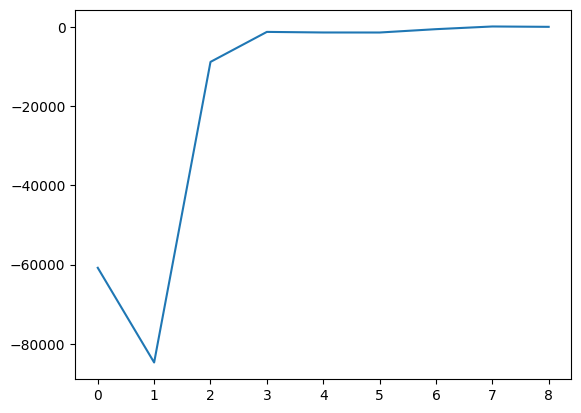

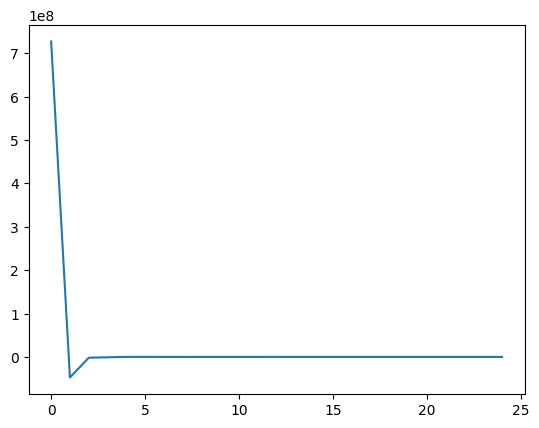

MGD L6: tensor([ True,  True,  True,  True, False, False, False, False, False])
REG L6: tensor([ True,  True,  True,  True,  True,  True,  True, False, False])
MGD L6 psi: tensor([ True, False, False, False, False, False, False,  True,  True,  True,
        False,  True, False,  True, False,  True,  True, False, False,  True,
         True,  True,  True,  True,  True])
REG L6 psi tensor([False,  True,  True,  True,  True, False,  True,  True,  True,  True,
         True,  True, False,  True,  True, False, False,  True, False, False,
        False, False, False, False, False])


In [13]:
final_reg_vals_L6 = final_reg_vals[:9]
final_reg_vals_L6_psi = final_reg_vals[9:34] 
final_mgd_vals_L6 = final_mgd_vals[:9]
final_mgd_vals_L6_psi = final_mgd_vals[9:34] 
#plt.plot(final_mgd_vals_L6) 
%matplotlib inline 
plt.plot(final_reg_vals_L6) 
plt.show() 
#plt.plot(final_mgd_vals_L6_psi) 
plt.plot(final_reg_vals_L6_psi) 
plt.show() 

print("MGD L6:", final_mgd_vals_L6 < 0) 
print("REG L6:", final_reg_vals_L6 < 0) 
print("MGD L6 psi:", final_mgd_vals_L6_psi < 0) 
print("REG L6 psi", final_reg_vals_L6_psi < 0) 

In [15]:
final_reg_vals.shape 

torch.Size([272])

## KL divergence 

In [11]:
seed_keys = sorted(results.keys(), key=lambda k: int(k.replace("seed", "")))
theta_t_list = [results[k]['theta_t'].to(device) for k in seed_keys]
theta_reg_t_list = [results[k]['Theta_reg'].to(device) for k in seed_keys]
phi_X_list   = [results[k]['phi_X'].to(device) for k in seed_keys]

print("Computing KL divergence for MGD...")
kl_mgd = compute_expected_kl_divergence(theta_t_list, phi_X_list).cpu()
kl_reg = compute_expected_kl_divergence(theta_reg_t_list, phi_X_list).cpu()

print(kl_mgd.shape)
print(kl_reg.shape) 
kl_mgd[:10]

Computing KL divergence for MGD...
torch.Size([39704])
torch.Size([197])


tensor([8.5642e+09, 6.2244e+09, 5.7994e+09, 5.4320e+09, 5.3275e+09, 5.2277e+09,
        5.4909e+09, 5.3783e+09, 5.2836e+09, 5.4636e+09])

Final KL value for MGD and for REG: 1842.913818359375, 199.42327880859375
Cramer Rao bound: 0.0272


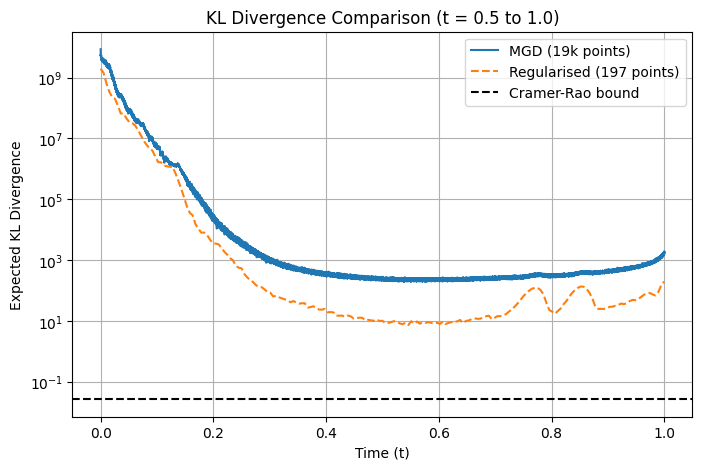

In [12]:
kl_mgd_np = kl_mgd.detach().cpu().numpy()
kl_reg_np = kl_reg.detach().cpu().numpy()

num_features = next(iter(results.values()))['phi_X'].shape[1]  # instead of the old global phi_X


print(f"Final KL value for MGD and for REG: {kl_mgd_np[-1]}, {kl_reg_np[-1]}") 
print(f"Cramer Rao bound: {num_features / (2 * n1)}") 
t_mgd = np.linspace(0, 1, len(kl_mgd_np))
t_reg = np.linspace(0, 1, len(kl_reg_np))
mask_mgd = t_mgd >= 0.0
mask_reg = t_reg >= 0.0

%matplotlib inline
plt.figure(figsize=(8, 5))
plt.plot(t_mgd[mask_mgd], kl_mgd_np[mask_mgd], label="MGD (19k points)")
plt.plot(t_reg[mask_reg], kl_reg_np[mask_reg], label="Regularised (197 points)", linestyle="--")
plt.axhline(num_features / (2 * n1), color="black", linestyle="--", label="Cramer-Rao bound")
plt.xlabel("Time (t)")
plt.ylabel("Expected KL Divergence")
plt.yscale("log")
plt.title("KL Divergence Comparison (t = 0.5 to 1.0)")
plt.legend()
plt.grid(True)
plt.show()

## Normalising constant 

This section used to reimplement its own `_entropy_bound_beforefinal` / `compute_log_Z_sigma` / `compute_m1` locally. Those had the sign on `theta_1^T m_1` backwards relative to this codebase's own `+theta^T phi(x)` convention (see the sign-convention audit at the top of `codes/utils_entropy.py`), used a left-Riemann `cumsum/nt` integral instead of trapezoidal integration over the actual saved `t` grid, and silently truncated `dH_t_bound`/`t` length mismatches with `min()` instead of surfacing them. They've been removed in favor of the audited `entropy_bound` / `log_Z_bound` (from `codes/utils_entropy.py`) and `plot_negentropy_convergence` (from `codes/check_moments.py`), already available below via this notebook's `from utils_entropy import *` / `from check_moments import *` at the top — no local reimplementation needed.

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

seed_numbers = []
logZ_mgd_list, logZ_reg_list = [], []
m1_mgd_list, m1_reg_list = [], []

for key in results.keys():
    match = re.search(r'\d+', key)
    if not match:
        continue
    seed_idx = int(match.group())

    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)

    try:
        out_mgd = log_Z_bound(results, key, 'theta_t', potentials_k, device=device)
        out_reg = log_Z_bound(results, key, 'Theta_reg', potentials_k, device=device)
    except ValueError as e:
        print(f"  [seed {seed_idx}] skipping: {e}")
        continue

    logZ_mgd = out_mgd['log_Z_bound']
    logZ_reg = out_reg['log_Z_bound']

    seed_numbers.append(seed_idx)
    logZ_mgd_list.append(logZ_mgd)
    logZ_reg_list.append(logZ_reg)
    m1_mgd_list.append(out_mgd['m1_particles'].norm().item())
    m1_reg_list.append(out_reg['m1_particles'].norm().item())

order = np.argsort(seed_numbers)
seeds_sorted = np.array(seed_numbers)[order]
logZ_mgd_arr = np.array(logZ_mgd_list)[order]
logZ_reg_arr = np.array(logZ_reg_list)[order]

# 3. Plotting for Variance & Consistency Assessment
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Subplot 1: Sequential check across individual seeds
axes[0].plot(seeds_sorted, logZ_mgd_arr, 'o-', color='tab:blue', alpha=0.7, label=r'MGD ($\theta_t$)')
axes[0].plot(seeds_sorted, logZ_reg_arr, 's--', color='tab:orange', alpha=0.7, label=r'Reg ($\Theta_{reg}$)')
axes[0].set_xlabel('Seed Number')
axes[0].set_ylabel(r'$\log Z_\sigma$ bound')
axes[0].set_title(r'$\log Z_\sigma$ Consistency Across Random Seeds')
axes[0].grid(True, ls=':', alpha=0.5)
axes[0].legend(frameon=False)

# Subplot 2: Distribution density to check variance/spread
axes[1].hist(logZ_mgd_arr, bins=12, alpha=0.5, color='tab:blue', label='MGD', edgecolor='black')
axes[1].hist(logZ_reg_arr, bins=12, alpha=0.5, color='tab:orange', label='Regularized', edgecolor='black')
axes[1].set_xlabel(r'Value of $\log Z_\sigma$ bound')
axes[1].set_ylabel('Frequency count')
axes[1].set_title('Distribution / Spread Comparison')
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# Quick summary statistics check printout
print(f"MGD Mean: {logZ_mgd_arr.mean():.4f}  | Std Dev: {logZ_mgd_arr.std():.4f}")
print(f"Reg Mean: {logZ_reg_arr.mean():.4f}  | Std Dev: {logZ_reg_arr.std():.4f}")

In [ ]:
# 1. Initialize collections
seed_numbers = []
negentropy_list = []
H_bound_list = []

# H(g): entropy of the Gaussian matching x1's OWN empirical covariance --
# NOT the standard-normal H(p_0), see the note in check_moments.py's
# plot_negentropy_convergence.
H_g = data_gaussian_entropy(x1)

# 2. Extract and compute negentropy across all seed runs
for key, res in results.items():
    # Safely parse the integer out of "seedX"
    match = re.search(r'\d+', key)
    if not match:
        continue
    seed_idx = int(match.group())

    potentials_k = get_potentials_for_seed(key, M, base_args, root, device)
    try:
        eb = entropy_bound(results, key, potentials_k, device=device, check_p0=False)
    except ValueError as e:
        print(f"  [seed {seed_idx}] skipping: {e}")
        continue

    # eb['H_bound'] is a LOWER bound on H(p_1^sigma), so H_g - H_bound is an
    # UPPER bound on the true negentropy H(g) - H(p_1^sigma), not an estimate.
    negentropy_val = H_g - eb['H_bound']

    seed_numbers.append(seed_idx)
    negentropy_list.append(negentropy_val)
    H_bound_list.append(eb['H_bound'])

# Sort arrays by seed number for cleaner sequential visualization
order = np.argsort(seed_numbers)
seeds_sorted = np.array(seed_numbers)[order]
negentropy_arr = np.array(negentropy_list)[order]

# Calculate statistical observables over the seed distribution
neg_mean = negentropy_arr.mean()
neg_std = negentropy_arr.std()

# 3. Plotting Consistency Profiles
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: Value vs Seed Number with a 1-sigma standard deviation band
axes[0].plot(seeds_sorted, negentropy_arr, 'o-', color='tab:blue', alpha=0.7, label=r'Seed Estimate ($H(g) - H_*^\sigma$)')
axes[0].axhline(y=neg_mean, color='tab:red', ls='--', alpha=0.8, label=f'Mean ({neg_mean:.4f})')
axes[0].fill_between(seeds_sorted, neg_mean - neg_std, neg_mean + neg_std, color='tab:red', alpha=0.1, label=r'$\pm 1$ Std Dev')
axes[0].set_xlabel('Seed Number')
axes[0].set_ylabel(r'Negentropy (upper bound) $H(g) - H_*^\sigma$')
axes[0].set_title('Negentropy Stability Across Seeds')
axes[0].grid(True, ls=':', alpha=0.5)
axes[0].legend(frameon=False)

# Right plot: Frequency density to visualize distribution geometry
axes[1].hist(negentropy_arr, bins=12, alpha=0.6, color='tab:blue', edgecolor='black')
axes[1].axvline(x=neg_mean, color='tab:red', ls='--')
axes[1].set_xlabel(r'Negentropy Value ($H(g) - H_*^\sigma$)')
axes[1].set_ylabel('Frequency Count')
axes[1].set_title('Distribution of Estimates')
axes[1].grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Print Summary Metrics
print(f"=== STATISTICAL OBSERVABLES OVER {len(negentropy_arr)} SEEDS ===")
print(f"Mean Negentropy : {neg_mean:.4f}")
print(f"Std Deviation   : {neg_std:.4f}")
print(f"Relative Spread : {(neg_std / abs(neg_mean)) * 100:.3f}%")

In [16]:
print(logZ_mgd, logZ_reg) 

-3810.00927734375 -6761.6224365234375
